1. На основе учебного ноутбука, проведите финальную подготовку данных. измените количество сегментирующих классов с `16` на `7`
 - 0_класс - FLOOR
 - 1_класс - CEILING
 - 2_класс - WALL
 - 3_класс - APERTURE, DOOR, WINDOW
 - 4_класс - COLUMN, RAILINGS, LADDER
 - 5_класс - INVENTORY
 - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Реализуйте сегментацию базы Стройка на основе модели `PSPnet`. Статья для изучения [Pyramid Scene Parsing Network](https://hszhao.github.io/projects/pspnet/) .


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

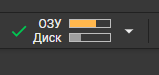


Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка


### Импорт библиотек

In [ ]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

import tensorflow as tf

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [ ]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -q 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:09<00:00, 21.9MB/s]


## Решение

## Глобальные параметры и загрузка данных

In [ ]:
# Глобальные параметры
IMG_WIDTH = 256
IMG_HEIGHT = 192
NUM_CLASSES = 16
TRAIN_DIRECTORY = 'train'
VAL_DIRECTORY = 'val'

# Загрузка оригинальных изображений
train_images = []
val_images = []

print("Загрузка оригинальных изображений...")
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original', filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original', filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

print(f"Train images: {len(train_images)}, Val images: {len(val_images)}")

# Загрузка сегментированных изображений
train_segments = []
val_segments = []

print("Загрузка масок...")
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')):
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment', filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))
for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')):
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment', filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

print(f"Train segments: {len(train_segments)}, Val segments: {len(val_segments)}")

Загрузка оригинальных изображений...
Train images: 1900, Val images: 100
Загрузка масок...
Train segments: 1900, Val segments: 100


## Подготовка данных: маппинг 16 классов в 7 классов

In [ ]:
# Цвета исходного датасета (16 классов)
CLASS_COLORS_16 = [
    (0, 0, 0), (100, 0, 0), (0, 100, 0), (100, 100, 0),
    (0, 0, 100), (100, 0, 100), (0, 100, 100), (100, 100, 100),
    (50, 0, 0), (0, 50, 0), (50, 50, 0), (0, 0, 50),
    (50, 0, 50), (0, 50, 50), (50, 50, 50), (200, 200, 200)
]

# Маппинг 16 -> 7 классов
# 0=FLOOR, 1=CEILING, 2=WALL, 3=APERTURE, 4=SUPPORT, 5=INVENTORY, 6=OTHER
MAP_16_TO_7 = np.array([
    0,  # 0 - FLOOR
    2,  # 1 - WALL
    2,  # 2 - WALL
    3,  # 3 - APERTURE
    4,  # 4 - COLUMN/SUPPORT
    1,  # 5 - CEILING
    5,  # 6 - INVENTORY
    6,  # 7 - LAMP/WIRE/OTHER
    2,  # 8 - WALL
    2,  # 9 - WALL
    3,  # 10 - DOOR
    3,  # 11 - WINDOW
    4,  # 12 - RAILINGS
    4,  # 13 - LADDER
    6,  # 14 - BEAM/OTHER
    6,  # 15 - BATTERY/PEOPLE
], dtype=np.int8)

NUM_CLASSES = 7

# Цвета для визуализации 7 классов
CLASS_COLORS_7 = [
    (128, 64, 64),   # 0 - FLOOR
    (64, 128, 64),   # 1 - CEILING
    (64, 64, 128),   # 2 - WALL
    (128, 128, 64),  # 3 - APERTURE
    (128, 64, 128),  # 4 - SUPPORT
    (64, 128, 128),  # 5 - INVENTORY
    (128, 128, 128), # 6 - OTHER
]

# Функция конвертации RGB маски в карту 7 классов
def build_color_lut(colors):
    lut = np.full(256**3, 255, dtype=np.uint8)
    for idx, (r, g, b) in enumerate(colors):
        key = (r << 16) | (g << 8) | b
        lut[key] = idx
    return lut

LUT_16 = build_color_lut(CLASS_COLORS_16)

def mask_rgb_to_class7(seg_img):
    seg_arr = np.array(seg_img, dtype=np.uint8)
    if seg_arr.shape[-1] == 4:
        seg_arr = seg_arr[..., :3]
    keys = ((seg_arr[...,0].astype(np.uint32) << 16) |
            (seg_arr[...,1].astype(np.uint32) << 8) |
            seg_arr[...,2].astype(np.uint32))
    cls16 = LUT_16[keys]
    cls16 = np.where(cls16 == 255, 0, cls16)
    return MAP_16_TO_7[cls16]

print("Подготовка данных...")

# X храним как uint8
x_train = np.array([np.asarray(img, dtype=np.uint8) for img in train_images])
x_val = np.array([np.asarray(img, dtype=np.uint8) for img in val_images])

print(f"x_train: {x_train.shape} dtype={x_train.dtype} ~{x_train.nbytes/1024/1024:.1f} MB")
print(f"x_val: {x_val.shape} ~{x_val.nbytes/1024/1024:.1f} MB")

# Y храним как int8 карту классов
h, w = np.array(train_segments[0]).shape[:2]
y_train = np.zeros((len(train_segments), h, w), dtype=np.int8)
y_val = np.zeros((len(val_segments), h, w), dtype=np.int8)

for i, seg in enumerate(train_segments):
    y_train[i] = mask_rgb_to_class7(seg)
for i, seg in enumerate(val_segments):
    y_val[i] = mask_rgb_to_class7(seg)

print(f"y_train: {y_train.shape} dtype={y_train.dtype} ~{y_train.nbytes/1024/1024:.1f} MB")
print(f"Уникальные классы: {np.unique(y_train)}")

# Очистка памяти
del train_images, val_images, train_segments, val_segments
gc.collect()

Подготовка данных...
x_train: (1900, 256, 192, 3) dtype=uint8 ~267.2 MB
x_val: (100, 256, 192, 3) ~14.1 MB
y_train: (1900, 256, 192) dtype=int8 ~89.1 MB
Уникальные классы: [0 1 2 3 4 5 6]


20135

## Метрика IoU

In [ ]:
def iou_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, tf.int32)
    intersection = tf.reduce_sum(tf.cast(tf.equal(y_true, y_pred), tf.float32))
    union = tf.reduce_sum(tf.cast(tf.not_equal(y_true, y_pred), tf.float32)) + intersection
    return intersection / (union + 1e-7)

## Архитектура PSPNet (Pyramid Pooling Module)

In [ ]:
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, AveragePooling2D, UpSampling2D,
                                     concatenate, Rescaling, Dropout, Resizing)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def conv_bn_relu(x, filters, kernel_size=3, strides=1):
    x = Conv2D(filters, kernel_size, strides=strides, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def backbone(x, filters_base=32):
    # Блок 1
    x = conv_bn_relu(x, filters_base)
    x = conv_bn_relu(x, filters_base)
    x = MaxPooling2D(2)(x)  # /2

    # Блок 2
    x = conv_bn_relu(x, filters_base * 2)
    x = conv_bn_relu(x, filters_base * 2)
    x = MaxPooling2D(2)(x)  # /4

    # Блок 3
    x = conv_bn_relu(x, filters_base * 4)
    x = conv_bn_relu(x, filters_base * 4)
    x = MaxPooling2D(2)(x)  # /8

    # Блок 4 
    x = conv_bn_relu(x, filters_base * 8)
    x = conv_bn_relu(x, filters_base * 8)

    return x

def pyramid_pooling_module(x, pool_sizes=(1, 2, 3, 6)):
    h, w = x.shape[1], x.shape[2]
    c = x.shape[-1]
    branches = [x]

    for ps in pool_sizes:
        pool_h = max(h // ps, 1)
        pool_w = max(w // ps, 1)

        pooled = AveragePooling2D(pool_size=(pool_h, pool_w), strides=(pool_h, pool_w))(x)
        pooled = Conv2D(c // 4, 1, padding='same', use_bias=False)(pooled)
        pooled = BatchNormalization()(pooled)
        pooled = Activation('relu')(pooled)
        pooled = UpSampling2D(size=(pool_h, pool_w), interpolation='bilinear')(pooled)
        pooled = Resizing(h, w, interpolation='bilinear')(pooled)
        branches.append(pooled)

    return concatenate(branches, axis=-1)

def build_pspnet(input_shape, num_classes=7, filters_base=32):
    inputs = Input(shape=input_shape, dtype='uint8')
    x = Rescaling(1.0/255.0)(inputs)

    feat = backbone(x, filters_base)

    ppm = pyramid_pooling_module(feat)

    x = conv_bn_relu(ppm, filters_base * 4)
    x = Dropout(0.1)(x)

    x = UpSampling2D(size=(8, 8), interpolation='bilinear')(x)
    x = Resizing(input_shape[0], input_shape[1], interpolation='bilinear')(x)

    x = conv_bn_relu(x, filters_base * 2)
    outputs = Conv2D(num_classes, 1, activation='softmax', padding='same')(x)

    model = Model(inputs=inputs, outputs=outputs, name='PSPNet')
    return model


## Обучение PSPNet на 60 эпох (с EarlyStopping)

In [ ]:
EPOCHS = 60
BATCH_SIZE = 8

_, H, W, _ = x_train.shape
print(f"Размер входных данных: H={H}, W={W}")

# Строим модель
model = build_pspnet(input_shape=(H, W, 3), num_classes=NUM_CLASSES, filters_base=32)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', iou_coef]
)

# Датасеты
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(512).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]


history_pspnet = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print(f"Финальная val_accuracy: {history_pspnet.history['val_accuracy'][-1]:.4f}")
print(f"Финальная val_iou: {history_pspnet.history['val_iou_coef'][-1]:.4f}")

Размер входных данных: H=256, W=192
Epoch 1/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 89s 256ms/step - accuracy: 0.6515 - iou_coef: 0.6515 - loss: 0.9964 - val_accuracy: 0.3477 - val_iou_coef: 0.3484 - val_loss: 1.8813 - learning_rate: 0.0010
Epoch 2/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 35s 145ms/step - accuracy: 0.7129 - iou_coef: 0.7129 - loss: 0.8114 - val_accuracy: 0.6279 - val_iou_coef: 0.6287 - val_loss: 1.1538 - learning_rate: 0.0010
Epoch 3/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 35s 145ms/step - accuracy: 0.7424 - iou_coef: 0.7424 - loss: 0.7372 - val_accuracy: 0.6355 - val_iou_coef: 0.6379 - val_loss: 0.9831 - learning_rate: 0.0010
Epoch 4/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 34s 144ms/step - accuracy: 0.7611 - iou_coef: 0.7612 - loss: 0.6816 - val_accuracy: 0.6776 - val_iou_coef: 0.6787 - val_loss: 0.9171 - learning_rate: 0.0010
Epoch 5/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 34s 145ms/step - accuracy: 0.7771 - iou_coef: 0.7768 - loss: 0.6355 - val_accuracy: 0.6630 - val_iou_coef: 0.6627 - val_loss: 0.9355 - l

## Визуализация графиков обучения (Accuracy, IoU, Loss)

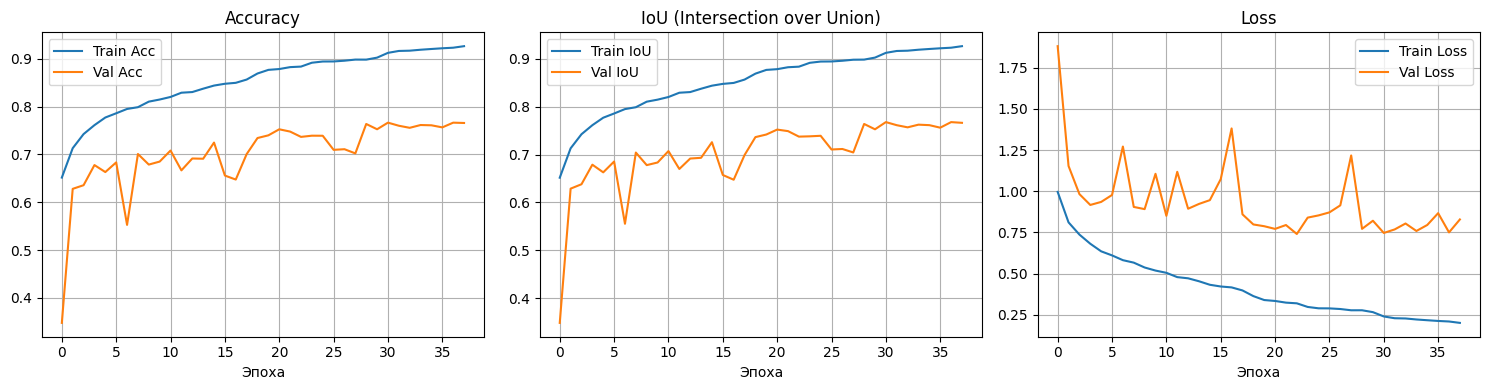

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_pspnet.history['accuracy'], label='Train Acc')
axes[0].plot(history_pspnet.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Эпоха')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_pspnet.history['iou_coef'], label='Train IoU')
axes[1].plot(history_pspnet.history['val_iou_coef'], label='Val IoU')
axes[1].set_title('IoU (Intersection over Union)')
axes[1].set_xlabel('Эпоха')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history_pspnet.history['loss'], label='Train Loss')
axes[2].plot(history_pspnet.history['val_loss'], label='Val Loss')
axes[2].set_title('Loss')
axes[2].set_xlabel('Эпоха')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Визуализация предсказаний PSPNet (3 примера)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


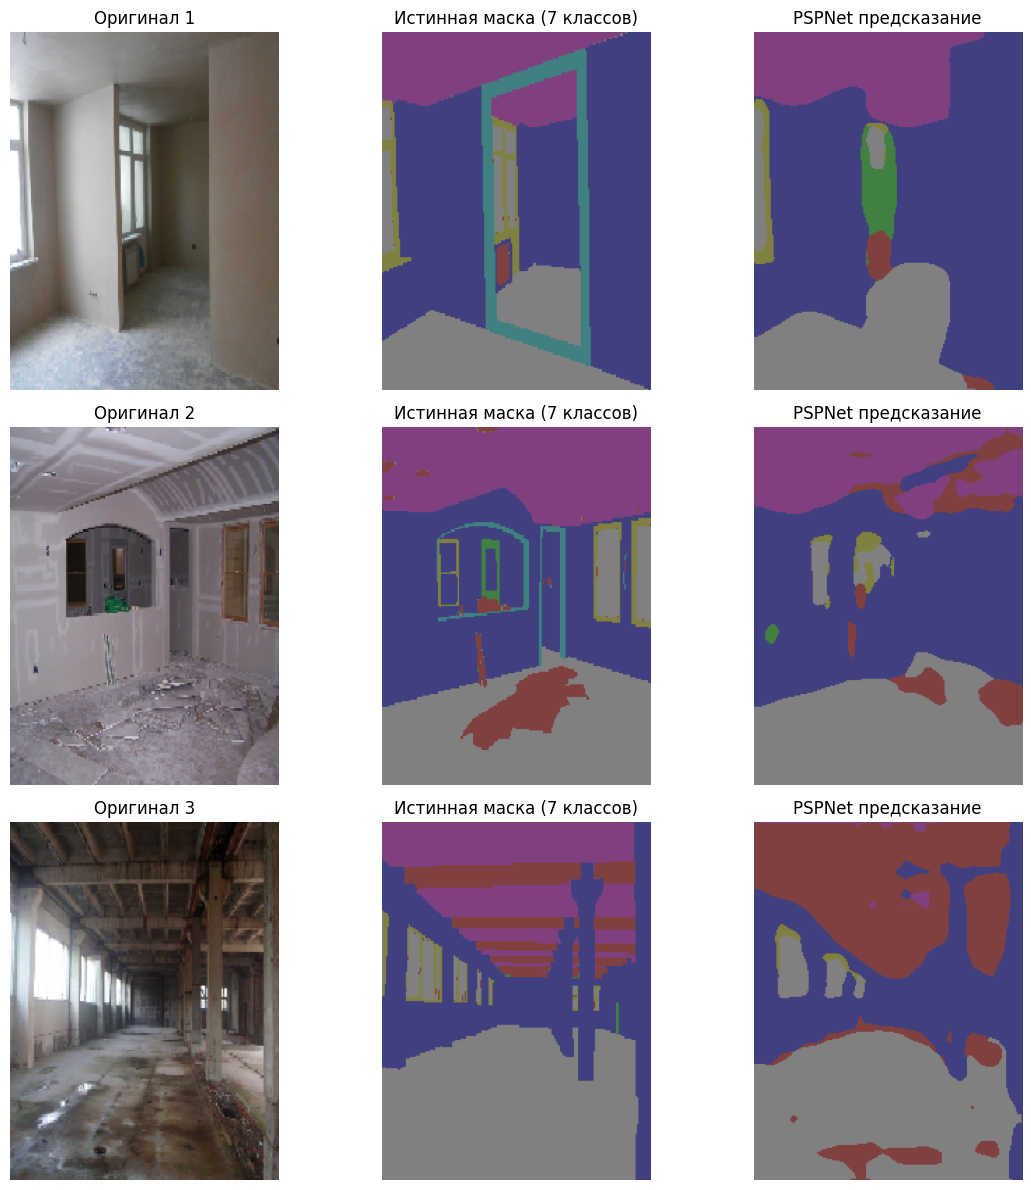


IoU на показанных примерах:
  Пример 1: IoU = 0.8485
  Пример 2: IoU = 0.7563
  Пример 3: IoU = 0.6561


In [ ]:
def mask_to_rgb(mask, colors):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype='uint8')
    for i, color in enumerate(colors):
        rgb[mask == i] = color
    return rgb

num_samples = 3
predictions = model.predict(x_val[:num_samples])
pred_masks = np.argmax(predictions, axis=-1)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

for i in range(num_samples):
    axes[i, 0].imshow(x_val[i])
    axes[i, 0].set_title(f'Оригинал {i+1}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_to_rgb(y_val[i], CLASS_COLORS_7))
    axes[i, 1].set_title(f'Истинная маска (7 классов)')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mask_to_rgb(pred_masks[i], CLASS_COLORS_7))
    axes[i, 2].set_title(f'PSPNet предсказание')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

print("\nIoU на показанных примерах:")
for i in range(num_samples):
    intersection = np.sum((y_val[i] == pred_masks[i]) & (y_val[i] != 0))
    union = np.sum((y_val[i] != 0) | (pred_masks[i] != 0))
    iou = intersection / union if union > 0 else 0
    print(f"  Пример {i+1}: IoU = {iou:.4f}")